In [1]:
%pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 921.9/921.9 kB 22.8 MB/s eta 0:00:0000:01
Note: you may need to restart the kernel to use updated packages.


In [2]:
import os

train_imgs = os.listdir('/kaggle/input/car-object-detection/data/training_images')
test_imgs = os.listdir('/kaggle/input/car-object-detection/data/testing_images')

In [3]:
import pandas as pd

data = pd.read_csv('/kaggle/input/car-object-detection/data/train_solution_bounding_boxes (1).csv')
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 559 entries, 0 to 558
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   image   559 non-null    object 
 1   xmin    559 non-null    float64
 2   ymin    559 non-null    float64
 3   xmax    559 non-null    float64
 4   ymax    559 non-null    float64
dtypes: float64(4), object(1)
memory usage: 22.0+ KB


In [4]:
data.head()

,image,xmin,ymin,xmax,ymax
0,vid_4_1000.jpg,281.259045,187.035071,327.727931,223.225547
1,vid_4_10000.jpg,15.163531,187.035071,120.329957,236.430180
2,vid_4_10040.jpg,239.192475,176.764801,361.968162,236.430180
3,vid_4_10020.jpg,496.483358,172.363256,630.020260,231.539575
4,vid_4_10060.jpg,16.630970,186.546010,132.558611,238.386422


In [5]:
os.makedirs('/kaggle/working/dataset', exist_ok=True)

for data_type in ["images", "labels"]:
    for subset in ["train", "test", "val"]:
        os.makedirs(os.path.join('/kaggle/working/dataset/', data_type, subset), exist_ok=True)

In [6]:
import shutil
from PIL import Image

def gen_annot(df, folder):
    for idx, row in df.iterrows():
        name = row['image']
        xmin = row.get('xmin')
        ymin = row.get('ymin')
        xmax = row.get('xmax')
        ymax = row.get('ymax')

        w = xmax - xmin
        h = ymax - ymin
        c_x = xmin + w / 2
        c_y = ymin + h / 2

        path = os.path.join('/kaggle/input/car-object-detection/data/training_images/', name)

        with Image.open(path) as img:
            img_w, img_h = img.size

        c_x /= img_w
        c_y /= img_h
        w /= img_w
        h /= img_h

        class_id = 0

        annot = f"{class_id} {c_x} {c_y} {w} {h}\n"

        annot_file = os.path.join('/kaggle/working/dataset/labels/', folder, os.path.splitext(name)[0] + '.txt')
            
        with open(annot_file, 'a') as file:
            file.write(annot)

        shutil.copy(path, os.path.join('/kaggle/working/dataset/images/', folder, name))

In [7]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(data, test_size=0.2)

os.makedirs('/kaggle/working/dataset', exist_ok=True)

gen_annot(train_df, 'train')
gen_annot(val_df, 'val')

In [8]:
for img in test_imgs:
    shutil.copy('/kaggle/input/car-object-detection/data/testing_images/' + img, '/kaggle/working/dataset/images/test/' + img)

In [9]:
yaml = f"""
path: /kaggle/working/
train:  ../dataset/images/train/
val:  ../dataset/images/val/
test: ../dataset/images/test/

# number of classes
nc: 1

# class names
names: ['car']
"""

with open('car_detection.yaml', 'w') as file:
    file.write(yaml)

In [10]:
from ultralytics import YOLO

model = YOLO("yolo11n.pt")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


100%|██████████| 5.35M/5.35M [00:00<00:00, 120MB/s]


In [11]:
results = model.train(data='car_detection.yaml', epochs=50, imgsz=650, batch=16, name='car_detection_model')

Ultralytics 8.3.80 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
engine/trainer: task=detect, mode=train, model=yolo11n.pt, data=car_detection.yaml, epochs=50, time=None, patience=100, batch=16, imgsz=650, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=car_detection_model, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_labels=True, show_con

100%|██████████| 755k/755k [00:00<00:00, 25.9MB/s]


Overriding model.yaml nc=80 with nc=1

                   from  n    params  module                                       arguments                     
  0                  -1  1       464  ultralytics.nn.modules.conv.Conv             [3, 16, 3, 2]                 
  1                  -1  1      4672  ultralytics.nn.modules.conv.Conv             [16, 32, 3, 2]                
  2                  -1  1      6640  ultralytics.nn.modules.block.C3k2            [32, 64, 1, False, 0.25]      
  3                  -1  1     36992  ultralytics.nn.modules.conv.Conv             [64, 64, 3, 2]                
  4                  -1  1     26080  ultralytics.nn.modules.block.C3k2            [64, 128, 1, False, 0.25]     
  5                  -1  1    147712  ultralytics.nn.modules.conv.Conv             [128, 128, 3, 2]              
  6                  -1  1     87040  ultralytics.nn.modules.block.C3k2            [128, 128, 1, True]           
  7                  -1  1    295424  ultralytics

train: Scanning /kaggle/working/dataset/labels/train... 303 images, 0 backgrounds, 0 corrupt: 100%|██████████| 303/303 [00:00<00:00, 1229.50it/s]

train: New cache created: /kaggle/working/dataset/labels/train.cache


...


50 epochs completed in 0.081 hours.
Optimizer stripped from runs/detect/car_detection_model/weights/last.pt, 5.5MB
Optimizer stripped from runs/detect/car_detection_model/weights/best.pt, 5.5MB

Validating runs/detect/car_detection_model/weights/best.pt...
Ultralytics 8.3.80 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
YOLO11n summary (fused): 100 layers, 2,582,347 parameters, 0 gradients, 6.3 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 4/4 [00:00<00:00,  4.28it/s]


                   all        100        112       0.59      0.982      0.646      0.434


/usr/local/lib/python3.10/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
/usr/local/lib/python3.10/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


Speed: 0.1ms preprocess, 1.8ms inference, 0.0ms loss, 2.3ms postprocess per image
Results saved to runs/detect/car_detection_model


In [12]:
evaluations = model.val()

Ultralytics 8.3.80 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
YOLO11n summary (fused): 100 layers, 2,582,347 parameters, 0 gradients, 6.3 GFLOPs


val: Scanning /kaggle/working/dataset/labels/val.cache... 100 images, 0 backgrounds, 0 corrupt: 100%|██████████| 100/100 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  5.20it/s]


                   all        100        112       0.59      0.982      0.646      0.434


/usr/local/lib/python3.10/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
/usr/local/lib/python3.10/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


Speed: 2.0ms preprocess, 3.7ms inference, 0.0ms loss, 0.7ms postprocess per image
Results saved to runs/detect/car_detection_model2


In [13]:
def plot_graphs(graphs, size):
    plt.figure(figsize=(15, 10))
    
    idx = 1
    
    for graph in graphs:
        plt.subplot(size[0], size[1], idx)
        graph = plt.imread('/kaggle/working/runs/detect/car_detection_model/' + graph)
        plt.imshow(graph)
        idx += 1
        
    plt.show()

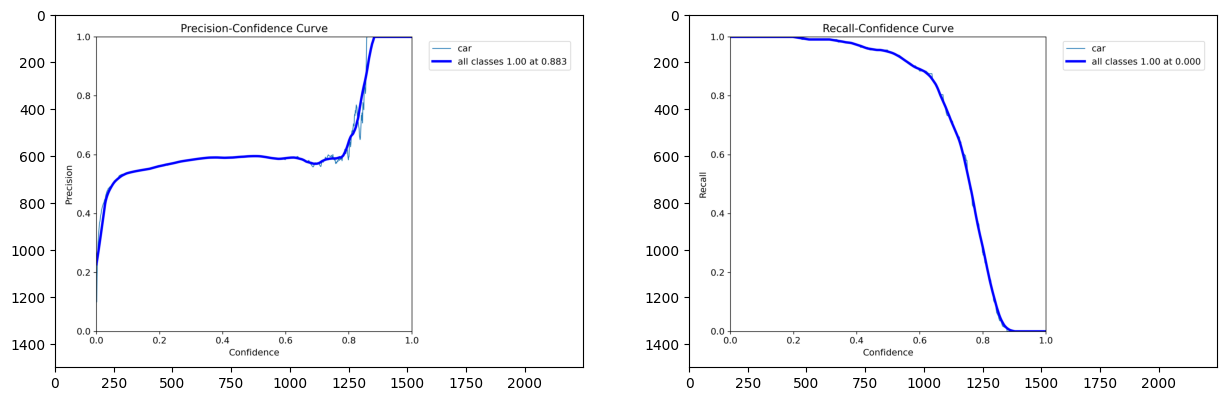

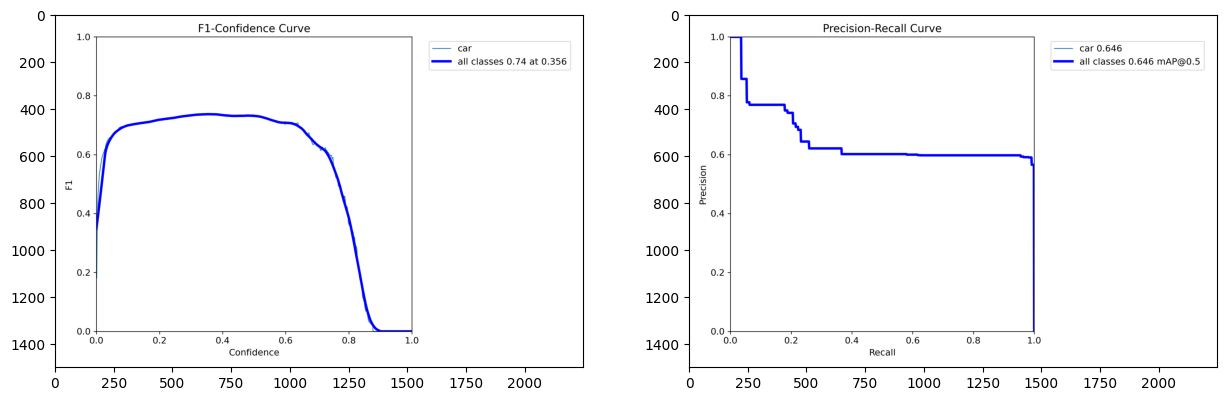

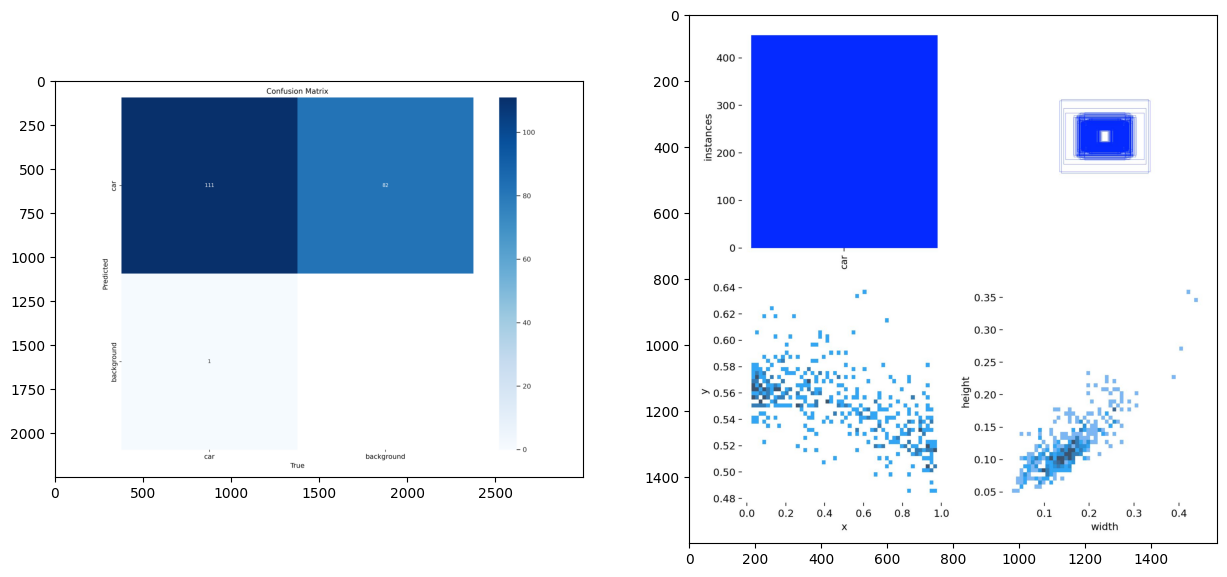

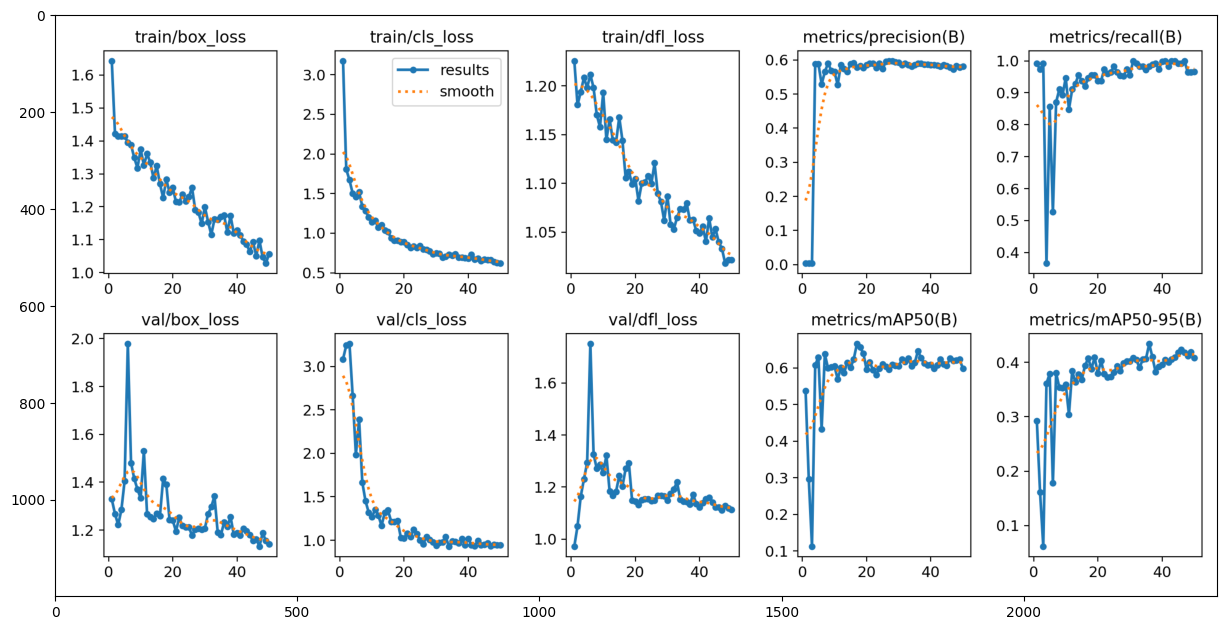

In [14]:
import matplotlib.pyplot as plt

plot_graphs(['P_curve.png', 'R_curve.png'], (1, 2))
plot_graphs(['F1_curve.png', 'PR_curve.png'], (1, 2))
plot_graphs(['confusion_matrix.png', 'labels.jpg'], (1, 2))
plot_graphs(['results.png'], (1, 1))


image 1/1 /kaggle/working/dataset/images/test/vid_5_31720.jpg: 384x672 1 car, 9.7ms
Speed: 1.9ms preprocess, 9.7ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 672)


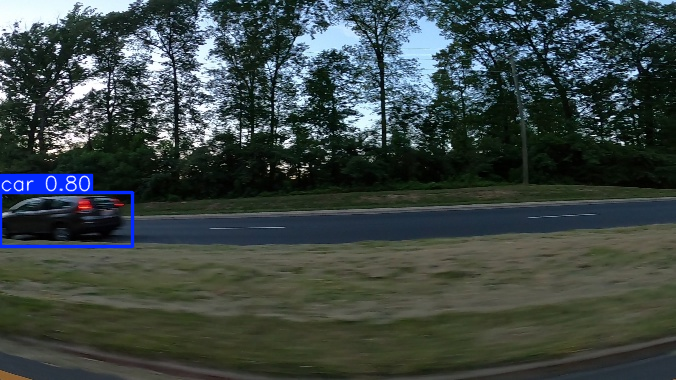


image 1/1 /kaggle/working/dataset/images/test/vid_5_29100.jpg: 384x672 (no detections), 7.9ms
Speed: 1.7ms preprocess, 7.9ms inference, 0.5ms postprocess per image at shape (1, 3, 384, 672)


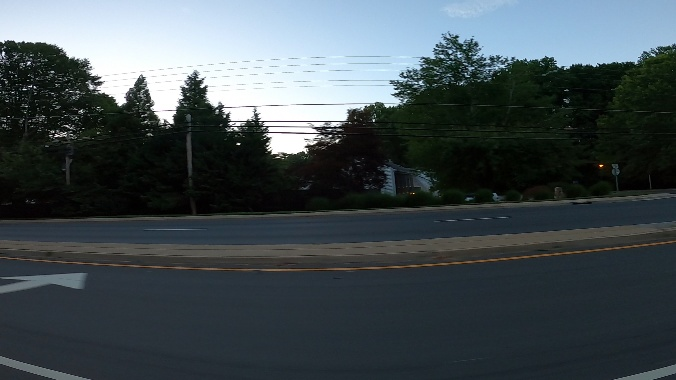


image 1/1 /kaggle/working/dataset/images/test/vid_5_26740.jpg: 384x672 3 cars, 8.1ms
Speed: 2.2ms preprocess, 8.1ms inference, 1.1ms postprocess per image at shape (1, 3, 384, 672)


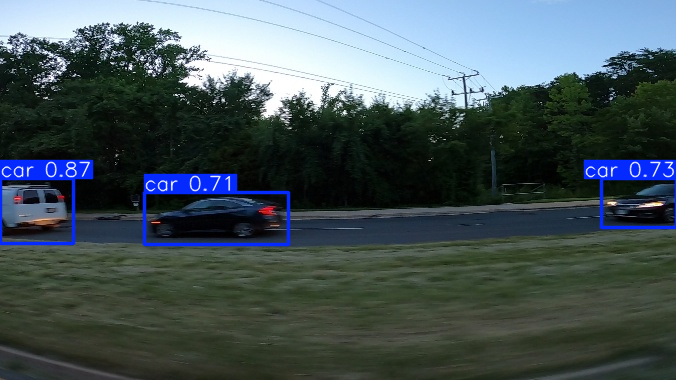


image 1/1 /kaggle/working/dataset/images/test/vid_5_26860.jpg: 384x672 1 car, 7.6ms
Speed: 1.6ms preprocess, 7.6ms inference, 1.1ms postprocess per image at shape (1, 3, 384, 672)


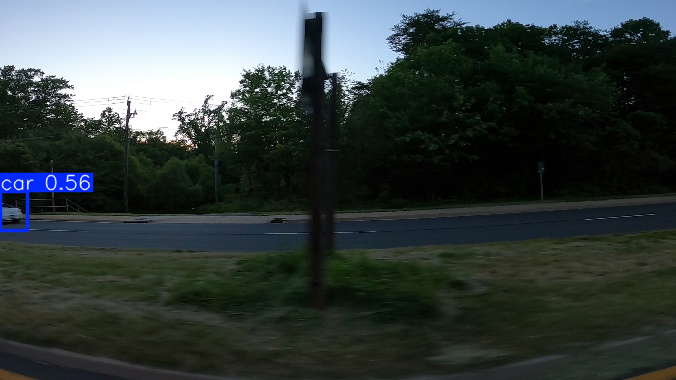


image 1/1 /kaggle/working/dataset/images/test/vid_5_26820.jpg: 384x672 2 cars, 8.8ms
Speed: 2.1ms preprocess, 8.8ms inference, 1.1ms postprocess per image at shape (1, 3, 384, 672)


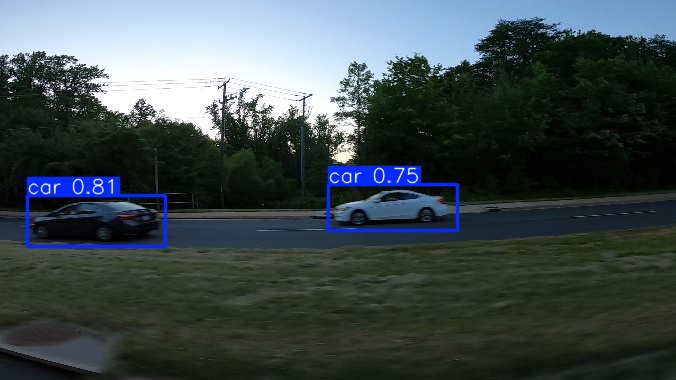

<Figure size 1000x800 with 0 Axes>

In [38]:
import random

imgs = random.sample(os.listdir('/kaggle/working/dataset/images/test/'), 5)

plt.figure(figsize=(10, 8))

for img in imgs:
    preds = model('/kaggle/working/dataset/images/test/' + img)
    preds[0].show()